# **E-Commerce Order Fulfillment Analysis**

## *Introduction*

### *Project Overview*

In this project, we analyze the order fulfillment process of an e-commerce business. We focus on sales trends, product performance, customer spending behavior, shipping cost optimization, and payment trends.

By leveraging SQL and Python, we extract and analyze data from an e-commerce orders database, helping businesses make data-driven decisions to improve logistics, sales, and customer experience.

### **Objective**

The key objectives of this project are:
*  Analyze order processing efficiency – Track processing delays and optimize fulfillment times.
*  Identify top-selling products – Discover which products generate the most revenue.
*  Segment high-value customers – Understand spending patterns and customer preferences.
*  Optimize shipping costs – Evaluate the relationship between order priority and shipping expenses.
*  Identify preferred payment methods – Analyze how customers choose to pay for their purchases.

By addressing these objectives, we can uncover business insights that help improve supply chain efficiency, increase revenue, and enhance customer satisfaction.

### *🛠 Tools & Technologies Used*

This project is implemented using a combination of SQL and Python to perform data extraction, analysis, and visualization.

* SQLite - Database management & query execution
* SQL - Extracting, transforming, and analyzing data
* Pandas - Data manipulation and transformation
* Matplotlib & Seaborn - Data visualization for insights
* DB Browser for SQLite - GUI tool for managing SQLite databases

### **Dataset Overview**

The dataset used in this project originates from an e-commerce platform and contains 51,290 rows with 16 columns. It provides insights into customer orders, product categories, sales trends, and shipping details.

 Dataset Summary
* Total Records: 51,290
* Total Columns: 16
* Data Types:
  * Numerical Columns: Sales, Quantity, Discount, Profit, Shipping_Cost, Aging
  * Categorical Columns: Gender, Device_Type, Customer_Login_type, Product_Category, Product, Order_Priority, Payment_method
  * Date & Time Columns: Order_Date, Time


In [7]:
import sqlite3
import pandas as pd

# Connection Establishment
conn = sqlite3.connect("Ecommerce_SQL_DATAProject.db")

query = "SELECT * FROM orders LIMIT 5;"
df = pd.read_sql_query(query,conn)
print(df)
conn.close()

   Order_Id  Order_Date      Time  Aging  Customer_Id  Gender Device_Type  \
0         1  2018-01-02  10:56:33      8        37077  Female         Web   
1         2  2018-07-24  20:41:37      2        59173  Female         Web   
2         3  2018-11-08  08:38:49      8        41066  Female         Web   
3         4  2018-04-18  19:28:06      7        50741  Female         Web   
4         5  2018-08-13  21:18:39      9        53639  Female         Web   

  Customer_Login_type            Product    Product_Category  Sales  Quantity  \
0              Member  Car Media Players  Auto & Accessories  140.0         1   
1              Member       Car Speakers  Auto & Accessories  211.0         1   
2              Member    Car Body Covers  Auto & Accessories  117.0         5   
3              Member    Car & Bike Care  Auto & Accessories  118.0         1   
4              Member               Tyre  Auto & Accessories  250.0         1   

   Discount  Profit  Shipping_Cost Order_Priority 

In [2]:
db_path = "./Ecommerce_SQL_DATAProject.db"
conn = sqlite3.connect(db_path)

basic_queries = {
    "Total Sales and Profit Summary": """
    SELECT
        SUM(Sales) AS Total_Sales,
        SUM(Profit) AS Total_Profit,
        ROUND(SUM(Profit) * 100.0 / SUM(Sales), 2) AS Profit_Margin_Pct
    FROM Orders;
""",
"Monthly Sales Performance": """
    SELECT strftime('%Y-%m', Order_Date) AS Month, SUM(Sales) AS Monthly_Sales, SUM(Profit) AS Monthly_Profit
        FROM Orders
        GROUP BY Month
        ORDER BY Month;
""",
"Top Selling Products":"""
SELECT P.Product_Name, P.Product_Category, SUM(O.Sales) AS Total_Sales, SUM(O.Quantity) AS Total_Units_Sold
        FROM Orders O
        JOIN Products P ON O.Product_Id = P.Product_Id
        GROUP BY P.Product_Name, P.Product_Category
        ORDER BY Total_Sales DESC
        LIMIT 10;
""",
"Customer Segmentation by Order Volume": """
    SELECT DISTINCT Customer_Id , COUNT(Order_Id) AS Total_orders , SUM(Sales) AS Total_spent 
    FROM orders GROUP BY Customer_Id ORDER BY Total_spent DESC LIMIT 10;
""",
"Order Processing Performance": """
    SELECT AVG(Aging) AS Avg_Processing_Time FROM Orders;
""",
"Shipping Cost Analysis":"""SELECT Order_Priority, COUNT(Order_Id) AS Total_Orders, AVG(Shipping_Cost) AS Avg_Shipping_Cost
        FROM Orders
        GROUP BY Order_Priority
        ORDER BY Avg_Shipping_Cost DESC;
""",
"Payment Method Trends":"""
SELECT Payment_Method, COUNT(Order_Id) AS Total_Orders, SUM(Sales) AS Total_Revenue
        FROM Orders
        GROUP BY Payment_Method
        ORDER BY Total_Revenue DESC;
"""
}

results = {}
for key , query in basic_queries.items():
    results[key] = pd.read_sql_query(query,conn)

In [3]:
for name,df in results.items():
    print(f"\n {name} Results:")
    display(df.head())


 Total Sales and Profit Summary Results:


,Total_Sales,Total_Profit,Profit_Margin_Pct
0,7813411.0,3611186.6,46.22



 Monthly Sales Performance Results:


,Month,Monthly_Sales,Monthly_Profit
0,2018-01,379627.0,174573.6
1,2018-02,332495.0,153288.2
2,2018-03,435502.0,200936.8
3,2018-04,597312.0,277832.2
4,2018-05,824502.0,379386.3



 Top Selling Products Results:


...

,Avg_Processing_Time
0,5.255035



 Shipping Cost Analysis Results:


,Order_Priority,Total_Orders,Avg_Shipping_Cost
0,None,2,14.450000
1,Critical,3932,7.224014
2,High,15499,7.180928
3,Low,2424,6.976609
4,Medium,29433,6.948643



 Payment Method Trends Results:


,Payment_Method,Total_Orders,Total_Revenue
0,credit_card,38137,5819379.0
1,money_order,9629,1461269.0
2,e_wallet,2789,422750.0
3,debit_card,734,109979.0
4,not_defined,1,34.0


### *Explanation of queries and Rationale*
* *Total Sales and Profit Summary* query aggregates total sales and profit from the Orders table to provide an overall performance snapshot.
  * The business generated $7.8M in revenue, with a profit of 3.6M USD.
  * This indicates a profit margin of ~46.2%, which is relatively strong.
* *Monthly Sales Performance* query calculates sales and profit trends over time, and helps identify seasonal sales patterns.
* *Top Selling Products* query identifies the top-selling products by revenue and quantity, and helps understand which products contribute most to business revenue.
* *Customer Segmentation by Order Volume* query identifies high-value customers based on total spending and helps segment customers for loyalty programs.
* *Payment Method Trends* helps understand customer payment preferences and is useful for optimizing payment partnerships.


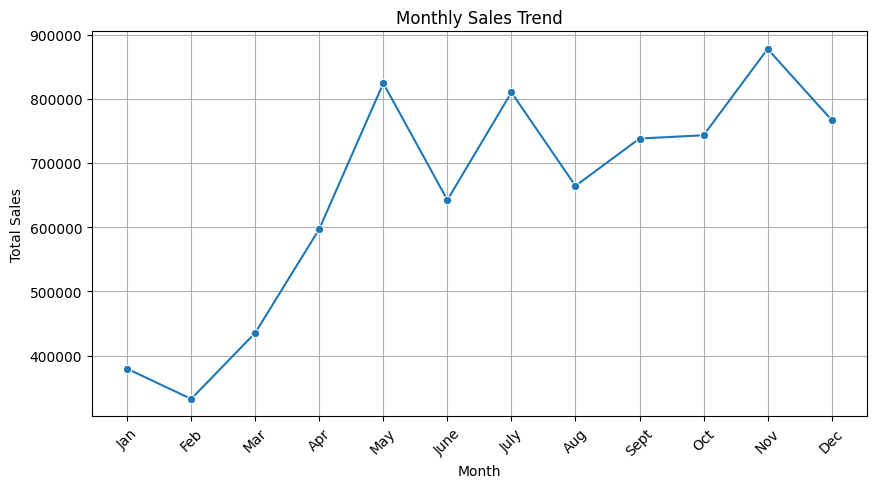

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

# Monthly Sales Performance Plot

df_monthly = results["Monthly Sales Performance"]
months = ["Jan","Feb","Mar","Apr" ,"May" , "June" , "July" , "Aug" , "Sept" , "Oct" , "Nov" , "Dec"]
plt.figure(figsize=(10,5))
sns.lineplot(x=months , y=df_monthly["Monthly_Sales"], marker="o")
plt.xticks(rotation=45)
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.grid(True)
plt.show()

Business Insight:
* Sales peaked in May and November, indicating possible seasonal trends.
* Sales declined in February, possibly due to off-season demand.
* Marketing campaigns should target peak sales months for maximum revenue.

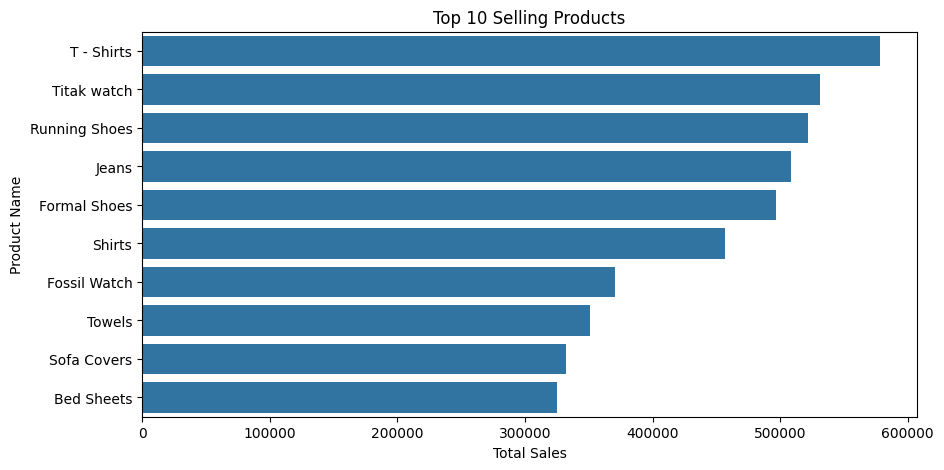

In [5]:
# Top selling products plot

df_top_products = results["Top Selling Products"]
plt.figure(figsize=(10,5))
sns.barplot(x=df_top_products["Total_Sales"] , y= df_top_products["Product_Name"])
plt.title("Top 10 Selling Products")
plt.xlabel("Total Sales")
plt.ylabel("Product Name")
plt.show()

 Business Insight:
* Fashion items dominate sales, with T-Shirts and Watches leading.
* Footwear (Running Shoes, Formal Shoes) also has high demand.
* Marketing should focus on these high-performing categories.

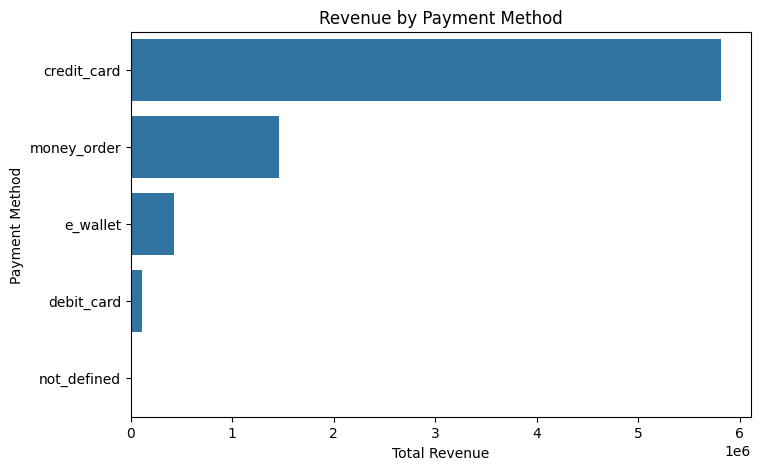

In [6]:
# Payment Method Trends Plot

df_payment = results["Payment Method Trends"]
plt.figure(figsize=(8,5))
sns.barplot(x=df_payment["Total_Revenue"], y=df_payment["Payment_Method"])
plt.title("Revenue by Payment Method")
plt.xlabel("Total Revenue")
plt.ylabel("Payment Method")
plt.show()

 Business Insight:
* 74% of total revenue comes from credit cards.
* E-wallet usage is low—potential for promotions to increase adoption.

In [7]:
adv_queries = {"Rank Products by Total Sales":
    """
    SELECT
        P.Product_Name,
        P.Product_Category,
        SUM(O.Sales) AS Total_Sales,
        RANK() OVER (ORDER BY SUM(O.Sales) DESC) AS Sales_Rank
    FROM Orders O
    JOIN Products P ON O.Product_Id = P.Product_Id
    GROUP BY P.Product_Name, P.Product_Category
    ORDER BY Total_Sales DESC;
    """ ,
    "Running Total of Monthly Sales": """
    WITH MonthlySales AS (
    SELECT
        strftime('%Y-%m', Order_Date) AS Month,
        SUM(Sales) AS Monthly_Sales
    FROM Orders
    GROUP BY Month
    ORDER BY Month
    )
    SELECT
    Month,
    Monthly_Sales,
    SUM(Monthly_Sales) OVER (ORDER BY Month ROWS BETWEEN UNBOUNDED PRECEDING AND CURRENT ROW) AS Running_Total
    FROM MonthlySales;
    """,
    "Customer Segmentation by Order Volume (Using CTE)": """
    WITH CustomerSpending AS (
    SELECT
        O.Customer_Id,
        SUM(O.Sales) AS Total_Sales,
        SUM(O.Profit) AS Total_Profit
    FROM Orders O
    GROUP BY O.Customer_Id
    )
    SELECT
    C.Customer_Id,
    C.Gender,
    CustomerSpending.Total_Sales,
    CustomerSpending.Total_Profit
    FROM CustomerSpending
    JOIN Customers C ON C.Customer_Id = CustomerSpending.Customer_Id
    ORDER BY CustomerSpending.Total_Sales DESC
    LIMIT 10;
    """,
    "Shipping Cost Analysis": """
    SELECT
      Order_Priority,
      COUNT(Order_Id) AS Total_Orders,
      AVG(Shipping_Cost) AS Avg_Shipping_Cost
      FROM Orders
      GROUP BY Order_Priority
      ORDER BY Avg_Shipping_Cost DESC;
    """
}

# Execute queries and store results
results = {}
for key, query in adv_queries.items():
    results[key] = pd.read_sql_query(query, conn)

In [8]:
for name, df in results.items():
    print(f"\n {name} Results:")
    display(df.head())


 Rank Products by Total Sales Results:


,Product_Name,Product_Category,Total_Sales,Sales_Rank
0,T - Shirts,Fashion,578336.0,1
1,Titak watch,Fashion,531468.0,2
2,Running Shoes,Fashion,522144.0,3
3,Jeans,Fashion,508376.0,4
4,Formal Shoes,Fashion,496503.0,5



 Running Total of Monthly Sales Results:


,Month,Monthly_Sales,Running_Total
0,2018-01,379627.0,379627.0
1,2018-02,332495.0,712122.0
2,2018-03,435502.0,1147624.0
3,2018-04,597312.0,1744936.0
4,2018-05,824502.0,2569438.0



 Customer Segmentation by Order Volume (Using CTE) Results:


,Customer_Id,Gender,Total_Sales,Total_Profit
0,87989,Male,994.0,497.9
1,35324,Male,949.0,489.3
2,79016,Male,935.0,443.2
3,10436,Male,929.0,546.9
4,51093,Female,927.0,505.8



 Shipping Cost Analysis Results:


,Order_Priority,Total_Orders,Avg_Shipping_Cost
0,None,2,14.450000
1,Critical,3932,7.224014
2,High,15499,7.180928
3,Low,2424,6.976609
4,Medium,29433,6.948643


### *Query Explanation & Rationale*
* *Rank Products by Total Sales (Using Window Functions)* query ranks the top-selling products using the RANK() window function. The ranking is based on total sales, with the highest-selling product ranked #1.
* *Running Total of Monthly Sales (Using Window Functions)* uses a Common Table Expression (CTE) to calculate monthly sales totals. The SUM() OVER() function computes a running total, allowing businesses to track cumulative revenue growth.
* *Customer Segmentation by Order Volume (Using CTE)* uses a CTE (Common Table Expression) to calculate total spending per customer, and helps businesses identify high-value customers for targeted promotions.
* *Shipping Cost Analysis* query analyzes the relationship between order priority and shipping costs, and helps businesses understand whether premium shipping options are over-utilized.

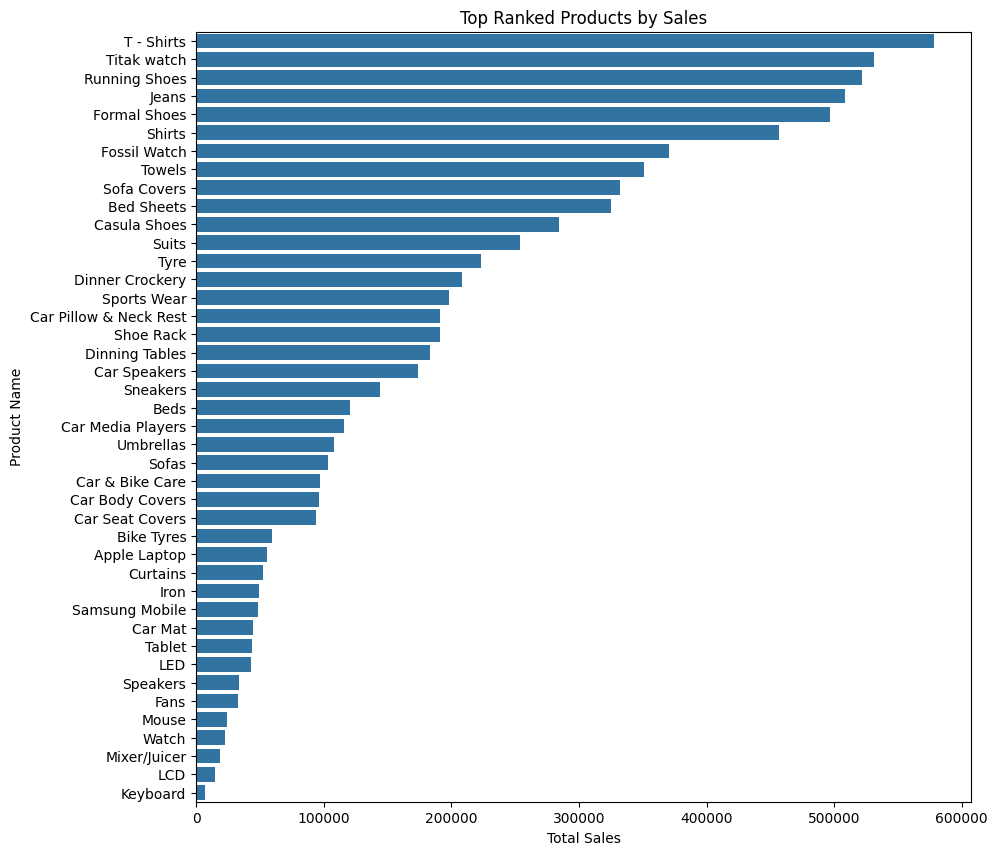

In [9]:
df_rank = results["Rank Products by Total Sales"]
plt.figure(figsize=(10, 10))
sns.barplot(x=df_rank["Total_Sales"], y=df_rank["Product_Name"])
plt.title("Top Ranked Products by Sales")
plt.xlabel("Total Sales")
plt.ylabel("Product Name")
plt.show()

 Business Insight:
* Fashion products dominate the rankings, with T-Shirts and Watches leading in revenue.
* Retailers should focus on inventory management for these high-performing items.
* Seasonal sales strategies should be aligned with these top-ranked products.


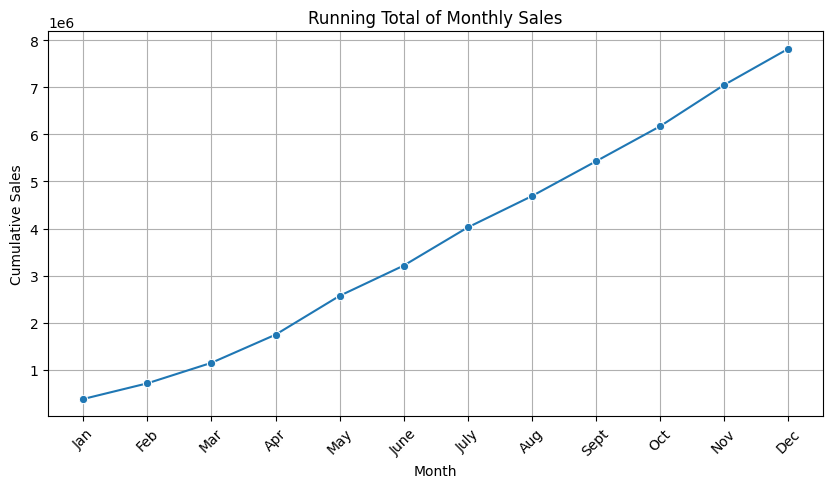

In [10]:
# Running Total of Monthly Sales
df_running_total = results["Running Total of Monthly Sales"]
plt.figure(figsize=(10, 5))
sns.lineplot(x=months, y=df_running_total["Running_Total"], marker="o")
plt.xticks(rotation=45)
plt.title("Running Total of Monthly Sales")
plt.xlabel("Month")
plt.ylabel("Cumulative Sales")
plt.grid(True)
plt.show()

 Business Insight:
* Sales steadily increased month-over-month, with a sharp rise in May and November.
* This suggests that certain months contribute significantly to revenue spikes.
* Marketing budgets should be allocated toward peak months.

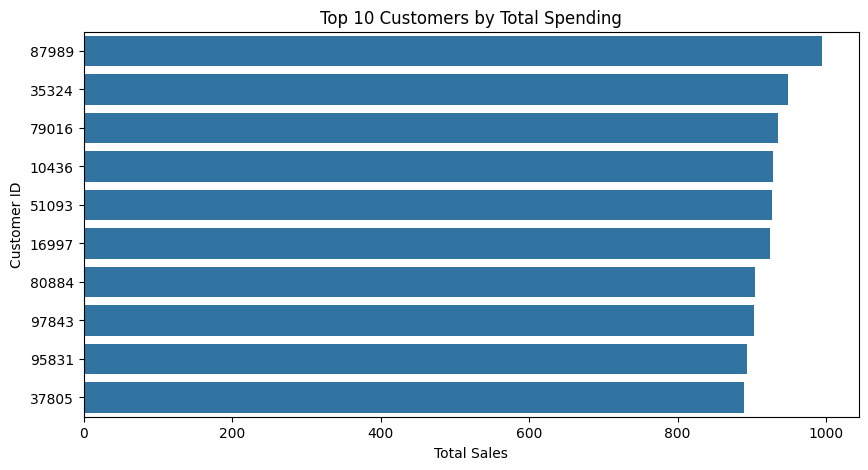

In [11]:
# Customer Segmentation by Order Volume
df_customer_segment = results["Customer Segmentation by Order Volume (Using CTE)"]
plt.figure(figsize=(10, 5))
sns.barplot(x=df_customer_segment["Total_Sales"], y=df_customer_segment["Customer_Id"].astype(str))
plt.title("Top 10 Customers by Total Spending")
plt.xlabel("Total Sales")
plt.ylabel("Customer ID")
plt.show()

Business Insight:
* Personalized discounts should be offered to these top customers to increase retention.
* Customer loyalty programs should be introduced for repeat buyers.

In [12]:
queries = {"Repeat Customer Rate": """WITH CustomerOrders AS(
	SELECT Customer_Id, COUNT(DISTINCT Order_Id) AS Total_orders FROM orders GROUP BY Customer_Id
)
SELECT COUNT(CASE WHEN Total_orders > 1 THEN 1 END) * 100.0 /COUNT(*) AS Repeat_Customer_Rate FROM CustomerOrders;""",

"Order distribution":"""WITH order_distribution as(
	SELECT Customer_Id , COUNT(DISTINCT Order_Id) AS Total_Orders FROM orders GROUP BY Customer_Id
)
SELECT
	CASE
		WHEN Total_Orders = 1 THEN '1 Orders'
        WHEN Total_Orders = 2 THEN '2 Orders'
        WHEN Total_Orders = 3 THEN '3 Orders'
        ELSE '4+ Orders'
	END AS Order_group , COUNT(*) AS Customers FROM order_distribution
GROUP BY Order_group
ORDER BY Customers DESC;""",

"Total Sales by gender": """SELECT c.Gender , SUM(o.Sales) AS Total_sales FROM customers c 
JOIN orders o
ON c.Customer_Id = o.Customer_Id
GROUP BY c.Gender;"""
}

results = {}
for key,query in queries.items():
    results[key] = pd.read_sql_query(query , conn)

In [13]:
for name, df in results.items():
    print(f"\n {name} Results:")
    display(df.head())


 Repeat Customer Rate Results:


,Repeat_Customer_Rate
0,26.068672



 Order distribution Results:


,Order_group,Customers
0,1 Orders,28831
1,2 Orders,8322
2,3 Orders,1595
3,4+ Orders,249



 Total Sales by gender Results:


,Gender,Total_sales
0,Female,3574837.0
1,Male,4238574.0


### *Query Explanation & Rationale*
* *Repeat Customer Rate* First, the CTE calculates the number of orders for each customer. Then it counts customers with more than one order and divides them by total customers.
* *Order Distribution* First calculates orders per customer, then categorizes customers into:
1 order
2 orders
3 orders
4+ orders
Finally, it counts how many customers fall into each group.
* *Total Sales by Gender* Joins the Customers and Orders tables using Customer_Id, then calculates total sales for each gender.

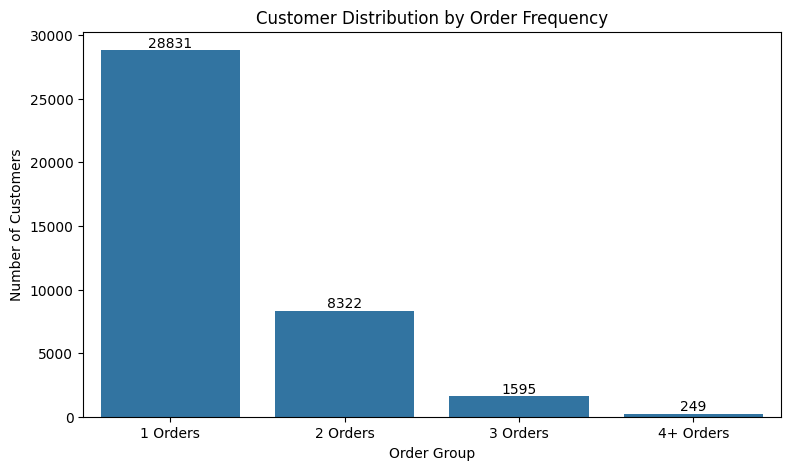

In [14]:
# Order Distribution
order_distribution = results["Order distribution"]

plt.figure(figsize=(9, 5))

ax = sns.barplot(
    data=order_distribution,
    x="Order_group",
    y="Customers"
)

# Add values on bars
for container in ax.containers:
    ax.bar_label(container)

plt.title("Customer Distribution by Order Frequency")
plt.xlabel("Order Group")
plt.ylabel("Number of Customers")

plt.show()

 Business Insight:
* The analysis shows that the majority of customers are one-time buyers, while relatively few customers make repeated purchases. This indicates an opportunity to improve customer retention through personalized offers, loyalty programs, and targeted follow-up campaigns.

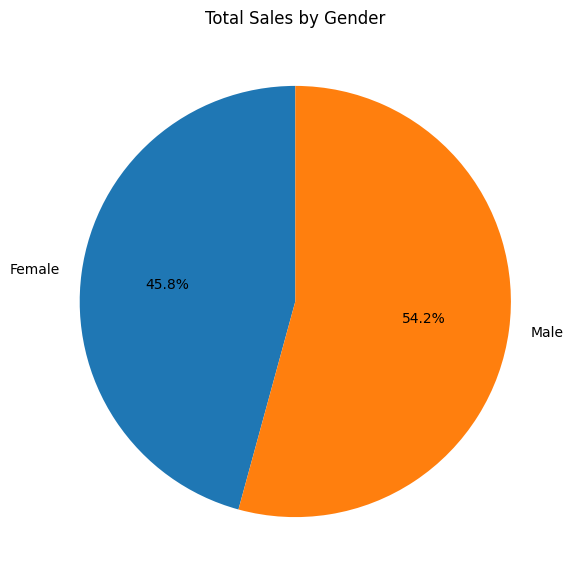

In [15]:
df_gender_sales = results["Total Sales by gender"]
plt.figure(figsize=(7, 7))

plt.pie(
    df_gender_sales["Total_sales"],
    labels=df_gender_sales["Gender"],
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Total Sales by Gender")

plt.show()

 Business Insight:
* The chart shows that male customers contribute a larger share of total sales:

Male: 54.2% ($4.24M)
Female: 45.8% ($3.57M)

The difference is: 4,238,574−3,574,837=$663,737

So male customers generated approximately $664K more sales than female customers.